# mnist dataset


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
from torchvision.datasets import MNIST

In [3]:
dataset = MNIST(root='data/', train=True, download=True,transform=transforms.ToTensor())

In [4]:
test_dataset = MNIST(root='data/', train=False)
len(test_dataset)

10000

In [5]:
img , lbl = test_dataset[0]
print(img.size, lbl)

(28, 28) 7


In [6]:
img_tensor, label = dataset[2]
print(img_tensor.shape, label)

torch.Size([1, 28, 28]) 4


In [7]:
dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [8]:
i , j =dataset[1]
i.T.shape

C:\Users\Prasad\AppData\Local\Temp\ipykernel_26052\3153136531.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3687.)
  i.T.shape


torch.Size([28, 28, 1])

Label: 0


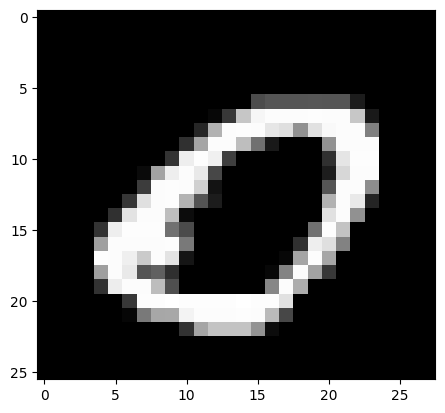

In [9]:
image, label = dataset[1]
plt.imshow(image.T[:-2], cmap='gray')
print('Label:', label)

In [10]:
dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()

# training dataset, validation dataset, test dataset

In [11]:
from torch.utils.data import random_split

train_ds, val_ds = random_split(dataset, [50000, 10000])
len(train_ds), len(val_ds)

(50000, 10000)

In [12]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size)

Now that we have prepared our data loaders, we can define our model.

A logistic regression model is almost identical to a linear regression model. It contains weights and bias matrices, and the output is obtained using simple matrix operations (pred = x
      @ w.t() + b).

As we did with linear regression, we can use nn.Linear to create the model instead of manually creating and initializing the matrices.

Since nn.Linear expects each training example to be a vector, each 1x28x28 image tensor is flattened into a vector of size 784 (28*28) before being passed into the model.

__The output for each image is a vector of size 10, with each element signifying the probability of a particular target label (i.e., 0 to 9). The predicted label for an image is simply the one with the highest probability.__

In [13]:
import torch.nn as nn

input_size = 28*28
num_classes = 10

# Logistic regression model
model = nn.Linear(input_size, num_classes)

In [14]:
print(model.weight.shape)
model.weight

torch.Size([10, 784])


Parameter containing:
tensor([[ 0.0172, -0.0174,  0.0232,  ...,  0.0096,  0.0301,  0.0172],
        [ 0.0341, -0.0216,  0.0171,  ...,  0.0261, -0.0305, -0.0147],
        [-0.0322,  0.0031, -0.0160,  ..., -0.0267, -0.0286,  0.0316],
        ...,
        [-0.0305,  0.0026, -0.0236,  ..., -0.0083, -0.0178,  0.0278],
        [ 0.0219, -0.0282, -0.0133,  ...,  0.0344,  0.0179,  0.0195],
        [ 0.0166,  0.0158,  0.0149,  ...,  0.0176,  0.0213,  0.0224]],
       requires_grad=True)

In [15]:
print(model.bias.shape)
model.bias

torch.Size([10])


Parameter containing:
tensor([ 0.0147,  0.0188, -0.0203,  0.0136, -0.0171, -0.0270, -0.0137,  0.0334,
         0.0009,  0.0141], requires_grad=True)

In [17]:
# Error

# for images, labels in train_loader:
#     print(labels)
#     print(images.shape)
#     outputs = model(images)
#     print(outputs)
#     break

The error message "RuntimeError: mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x10)" indicates a dimension mismatch during matrix multiplication in your code. Let's break down the shapes involved:

* images.shape: torch.Size([128, 1, 28, 28])
    * This represents a batch of 128 images, each with 1 channel (grayscale), and a height and width of 28 pixels.
* model.linear: This linear layer likely has an input size of 784 (28x28 pixels flattened) and an output size of 10 (representing the 10 digit classes).

__Root Cause:__

The issue arises because you're directly feeding the unflattened images (images) into the linear layer. The linear layer expects a flattened input vector of size 784 for each image, but it's receiving a 4D tensor instead. This mismatch in dimensions prevents the matrix multiplication from being performed correctly.

__Solution:__

To rectify this error, you need to flatten the images before passing them to the linear layer. Here's the corrected code snippet:



In [18]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = torch.sigmoid(self.linear(xb))
        return out

model = MnistModel()

In [19]:
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[-0.0251,  0.0238, -0.0139,  ...,  0.0207, -0.0100,  0.0289],
         [ 0.0170, -0.0299, -0.0230,  ...,  0.0312,  0.0231,  0.0037],
         [-0.0351,  0.0231, -0.0054,  ..., -0.0082,  0.0075, -0.0145],
         ...,
         [-0.0288,  0.0059,  0.0015,  ...,  0.0219,  0.0272,  0.0328],
         [-0.0186, -0.0279, -0.0190,  ..., -0.0120, -0.0055,  0.0173],
         [ 0.0229, -0.0030, -0.0252,  ..., -0.0076,  0.0207, -0.0046]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0180,  0.0077,  0.0352, -0.0210, -0.0224, -0.0240, -0.0217, -0.0100,
          0.0246,  0.0146], requires_grad=True)]

In [20]:
for images, labels in train_loader:
    print(images.shape)
    outputs = model(images)
    break

print('outputs.shape : ', outputs.shape)
print('Sample outputs :\n', outputs[:2].data) 

torch.Size([128, 1, 28, 28])
outputs.shape :  torch.Size([128, 10])
Sample outputs :
 tensor([[0.5278, 0.5291, 0.5005, 0.4859, 0.4243, 0.3926, 0.5524, 0.5234, 0.5086,
         0.4083],
        [0.5262, 0.5349, 0.5300, 0.4363, 0.4134, 0.4052, 0.5460, 0.5528, 0.4919,
         0.5478]])


In [21]:
outputs[0]

tensor([0.5278, 0.5291, 0.5005, 0.4859, 0.4243, 0.3926, 0.5524, 0.5234, 0.5086,
        0.4083], grad_fn=<SelectBackward0>)

__finally we can determine the predicted label for each image by simply choosing the index of the element with the highest probability in each output row. We can do this using torch.max, which returns each row's largest element and the corresponding index.__

In [22]:
max_probs, preds = torch.max(outputs, dim=1)
print(preds)
print(max_probs)

tensor([6, 7, 9, 6, 9, 9, 1, 6, 9, 8, 0, 6, 1, 7, 1, 3, 8, 6, 1, 0, 0, 9, 9, 7,
        5, 1, 5, 9, 0, 9, 9, 9, 4, 8, 8, 6, 9, 7, 7, 8, 7, 8, 6, 0, 7, 3, 9, 7,
        7, 9, 1, 9, 1, 9, 7, 7, 3, 0, 6, 8, 7, 7, 8, 7, 1, 0, 7, 2, 9, 7, 9, 1,
        3, 7, 3, 8, 7, 7, 7, 7, 7, 6, 7, 0, 0, 6, 7, 7, 6, 7, 8, 6, 8, 6, 8, 6,
        9, 7, 5, 8, 7, 0, 9, 7, 9, 7, 7, 9, 6, 9, 6, 7, 1, 7, 9, 8, 6, 6, 8, 7,
        7, 6, 7, 7, 2, 8, 1, 9])
tensor([0.5524, 0.5528, 0.5357, 0.5521, 0.6032, 0.5435, 0.5524, 0.5797, 0.5690,
        0.5750, 0.5509, 0.5330, 0.5843, 0.5682, 0.5350, 0.5058, 0.5799, 0.5153,
        0.5294, 0.5219, 0.5559, 0.5394, 0.5623, 0.5998, 0.5172, 0.5437, 0.5246,
        0.5345, 0.5512, 0.5265, 0.5680, 0.5597, 0.5177, 0.5389, 0.5436, 0.5761,
        0.5517, 0.5408, 0.5549, 0.5375, 0.5340, 0.5073, 0.5374, 0.5377, 0.5426,
        0.5318, 0.5609, 0.5708, 0.5829, 0.5363, 0.5554, 0.5718, 0.5051, 0.5598,
        0.5262, 0.5622, 0.5305, 0.6051, 0.6113, 0.5490, 0.5983, 0.5514, 0.5472,
       

In [23]:
outputs

tensor([[0.5278, 0.5291, 0.5005,  ..., 0.5234, 0.5086, 0.4083],
        [0.5262, 0.5349, 0.5300,  ..., 0.5528, 0.4919, 0.5478],
        [0.4627, 0.5150, 0.4849,  ..., 0.5140, 0.4573, 0.5357],
        ...,
        [0.5096, 0.5343, 0.4477,  ..., 0.4654, 0.5546, 0.5041],
        [0.4422, 0.5163, 0.4760,  ..., 0.4944, 0.4525, 0.4566],
        [0.4895, 0.4764, 0.4907,  ..., 0.4734, 0.4993, 0.5010]],
       grad_fn=<SigmoidBackward0>)

# torch.max()


.. function:: max(input, dim, keepdim=False, *, out=None) -> (Tensor, LongTensor)
   :noindex:

__Returns a namedtuple ``(values, indices)`` where ``values`` is the maximum
value of each row of the :attr:`input` tensor in the given dimension
:attr:`dim`. And ``indices`` is the index location of each maximum value found
(argmax).__


In [24]:
labels

tensor([6, 0, 6, 6, 6, 1, 6, 4, 7, 8, 7, 8, 6, 8, 4, 6, 6, 8, 2, 1, 7, 4, 4, 3,
        1, 7, 2, 1, 9, 4, 1, 8, 6, 3, 1, 8, 2, 3, 9, 1, 3, 7, 3, 4, 3, 0, 4, 7,
        9, 0, 4, 6, 2, 1, 1, 4, 4, 7, 3, 4, 5, 8, 2, 0, 2, 5, 7, 0, 6, 3, 2, 7,
        9, 9, 7, 3, 1, 8, 5, 9, 7, 3, 5, 9, 4, 8, 8, 9, 3, 6, 7, 4, 5, 5, 0, 8,
        9, 9, 1, 3, 4, 5, 2, 5, 2, 9, 9, 9, 6, 9, 2, 2, 2, 1, 7, 2, 6, 0, 5, 9,
        4, 8, 3, 4, 5, 2, 2, 4])

In [25]:
preds==labels

tensor([ True, False, False,  True, False, False, False, False, False,  True,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False,  True, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False,  True,  True,  True,
        False, False, False, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False, False])

In [26]:
torch.sum(preds==labels)

tensor(11)

In [28]:
# Error

# torch.tensor([13.,1.,12.,45.]).item()

In [29]:
torch.tensor([88.]).item()

88.0

In [30]:
torch.sum(preds==labels).item()


11

In [31]:
len(preds)

128

# evaluation metric and loss function

In [32]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item()/ len(preds))

In [33]:
accuracy(outputs, labels)

tensor(0.0859)

In [34]:
import torch.nn.functional as F

loss_fn = F.cross_entropy

# Loss for current batch of data
loss = loss_fn(outputs, labels)
print(loss)

tensor(2.3112, grad_fn=<NllLossBackward0>)


In [35]:
model.parameters

<bound method Module.parameters of MnistModel(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)>

In [36]:
opt = torch.optim.SGD(model.parameters(), lr=1e-5)

#Utility function to train the model
def fit(num_epochs, model, loss_fn, opt, train_dl):
    total = 0
    correct = 0

    for epoch in range(num_epochs):
        epoch_loss = 0
        epoch_acc = 0

        for xb, yb in train_dl:
            pred = model(xb) # generate prediction
            loss = loss_fn(pred, yb) # Calculate loss
            acc = accuracy(pred, yb) 
            loss.backward() # compute gradient
            opt.step() # update parameters using gradient
            opt.zero_grad() # reset the gradients to zero
            epoch_loss += loss.item() 
    
        #print the progress
        if (epoch+1) % 10 == 0:
            print('Epoch [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}'.format(epoch+1, num_epochs, loss.item(), acc))

fit(100, model, loss_fn, opt, train_loader)

Epoch [10/100], Loss: 2.3033, Accuracy: 0.08
Epoch [20/100], Loss: 2.3093, Accuracy: 0.10
Epoch [30/100], Loss: 2.3000, Accuracy: 0.10
Epoch [40/100], Loss: 2.2993, Accuracy: 0.08
Epoch [50/100], Loss: 2.3020, Accuracy: 0.14
Epoch [60/100], Loss: 2.3042, Accuracy: 0.14
Epoch [70/100], Loss: 2.2803, Accuracy: 0.20
Epoch [80/100], Loss: 2.2889, Accuracy: 0.17
Epoch [90/100], Loss: 2.2899, Accuracy: 0.19
Epoch [100/100], Loss: 2.2847, Accuracy: 0.22


# updated model

In [37]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
        
    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return out
        
    def training_step(self, batch):
        images, labels = batch
        out = self(images) # generate predictions
        loss = F.cross_entropy(out, labels)
        return loss
        
    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss':loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean() # combine losses
        batch_accs = [x['val_acc']for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean() # combine accuracies
        return {'val_loss':epoch_loss.item(), 'val_acc':epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

    def evaluate(self, val_loader):
        outputs = [self.validation_step(batch) for batch in val_loader]
        return self.validation_epoch_end(outputs)

In [56]:
t = torch.tensor([1, 2, 3, 4, 5], dtype = torch.float64)

torch.stack([t]).mean()

tensor(3., dtype=torch.float64)

In [67]:
model = MnistModel()

In [39]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
    optimizer = opt_func(model.parameters(), lr)
    history = []

    for epoch in range(epochs):

        # Training phase
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # validation phase
        result = model.evaluate(val_loader)
        model.epoch_end(epoch, result)
        history.append(result)

    return history




In [68]:
history0 = model.evaluate(val_loader)

In [69]:
history0

{'val_loss': 2.319448947906494, 'val_acc': 0.0579509511590004}

In [70]:
history1 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.9558, val_acc: 0.5929
Epoch [1], val_loss: 1.6864, val_acc: 0.7219
Epoch [2], val_loss: 1.4853, val_acc: 0.7602
Epoch [3], val_loss: 1.3339, val_acc: 0.7796
Epoch [4], val_loss: 1.2176, val_acc: 0.7946


In [71]:
history1

[{'val_loss': 1.9557818174362183, 'val_acc': 0.5928599834442139},
 {'val_loss': 1.6864371299743652, 'val_acc': 0.721914529800415},
 {'val_loss': 1.485268473625183, 'val_acc': 0.7601858973503113},
 {'val_loss': 1.3338515758514404, 'val_acc': 0.7795688509941101},
 {'val_loss': 1.2176454067230225, 'val_acc': 0.7946004867553711}]

In [72]:
history2 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.1264, val_acc: 0.8048
Epoch [1], val_loss: 1.0533, val_acc: 0.8118
Epoch [2], val_loss: 0.9934, val_acc: 0.8174
Epoch [3], val_loss: 0.9436, val_acc: 0.8216
Epoch [4], val_loss: 0.9016, val_acc: 0.8257


In [73]:
history2

[{'val_loss': 1.1263982057571411, 'val_acc': 0.8047863841056824},
 {'val_loss': 1.0532646179199219, 'val_acc': 0.8118077516555786},
 {'val_loss': 0.9934231042861938, 'val_acc': 0.8174446225166321},
 {'val_loss': 0.943625271320343, 'val_acc': 0.8215981125831604},
 {'val_loss': 0.9015547633171082, 'val_acc': 0.8256527185440063}]

In [74]:
history3 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.8655, val_acc: 0.8284
Epoch [1], val_loss: 0.8342, val_acc: 0.8337
Epoch [2], val_loss: 0.8069, val_acc: 0.8368
Epoch [3], val_loss: 0.7827, val_acc: 0.8398
Epoch [4], val_loss: 0.7611, val_acc: 0.8425


In [75]:
history3

[{'val_loss': 0.8654939532279968, 'val_acc': 0.8284216523170471},
 {'val_loss': 0.8342332243919373, 'val_acc': 0.8336629867553711},
 {'val_loss': 0.8068653345108032, 'val_acc': 0.8368275165557861},
 {'val_loss': 0.7826581597328186, 'val_acc': 0.8397942781448364},
 {'val_loss': 0.7611483931541443, 'val_acc': 0.8424643874168396}]

In [76]:
history = [history0] + history1 + history2 + history3
accuracies = [result['val_acc'] for result in history]
history, accuracies

([{'val_loss': 2.319448947906494, 'val_acc': 0.0579509511590004},
  {'val_loss': 1.9557818174362183, 'val_acc': 0.5928599834442139},
  {'val_loss': 1.6864371299743652, 'val_acc': 0.721914529800415},
  {'val_loss': 1.485268473625183, 'val_acc': 0.7601858973503113},
  {'val_loss': 1.3338515758514404, 'val_acc': 0.7795688509941101},
  {'val_loss': 1.2176454067230225, 'val_acc': 0.7946004867553711},
  {'val_loss': 1.1263982057571411, 'val_acc': 0.8047863841056824},
  {'val_loss': 1.0532646179199219, 'val_acc': 0.8118077516555786},
  {'val_loss': 0.9934231042861938, 'val_acc': 0.8174446225166321},
  {'val_loss': 0.943625271320343, 'val_acc': 0.8215981125831604},
  {'val_loss': 0.9015547633171082, 'val_acc': 0.8256527185440063},
  {'val_loss': 0.8654939532279968, 'val_acc': 0.8284216523170471},
  {'val_loss': 0.8342332243919373, 'val_acc': 0.8336629867553711},
  {'val_loss': 0.8068653345108032, 'val_acc': 0.8368275165557861},
  {'val_loss': 0.7826581597328186, 'val_acc': 0.8397942781448364},

Text(0.5, 1.0, 'Accuracy vs. No. of epochs')

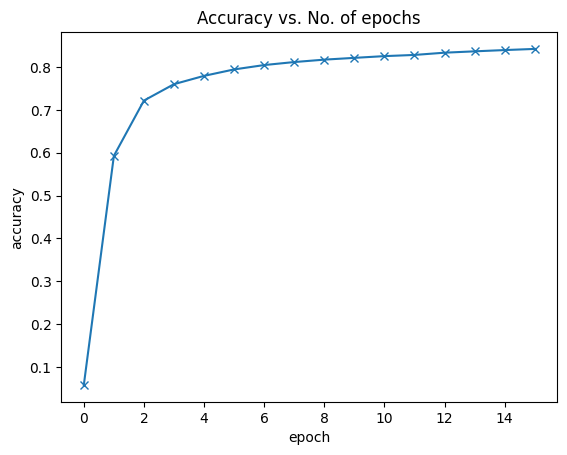

In [77]:
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs. No. of epochs')

__It's quite clear from the above picture that the model probably won't cross the accuracy threshold of 90% even after training for a very long time. One possible reason for this is that the learning rate might be too high. The model's parameters may be "bouncing" around the optimal set of parameters for the lowest loss. You can try reducing the learning rate and training for a few more epochs to see if it helps.__

__The more likely reason that the model just isn't powerful enough. If you remember our initial hypothesis, we have assumed that the output (in this case the class probabilities) is a linear function of the input (pixel intensities), obtained by perfoming a matrix multiplication with the weights matrix and adding the bias. This is a fairly weak assumption, as there may not actually exist a linear relationship between the pixel intensities in an image and the digit it represents. While it works reasonably well for a simple dataset like MNIST (getting us to 85% accuracy), we need more sophisticated models that can capture non-linear relationships between image pixels and labels for complex tasks like recognizing everyday objects, animals etc.__

# now we run history1 first then history0 and then history 2, 3

# __defining model again to get random weights__

In [78]:
model = MnistModel()

In [79]:
history1 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.9700, val_acc: 0.5911
Epoch [1], val_loss: 1.7001, val_acc: 0.7207
Epoch [2], val_loss: 1.4978, val_acc: 0.7614
Epoch [3], val_loss: 1.3446, val_acc: 0.7838
Epoch [4], val_loss: 1.2266, val_acc: 0.7986


In [80]:
history0 = model.evaluate(val_loader)

In [81]:
history2 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.1339, val_acc: 0.8080
Epoch [1], val_loss: 1.0594, val_acc: 0.8133
Epoch [2], val_loss: 0.9986, val_acc: 0.8181
Epoch [3], val_loss: 0.9479, val_acc: 0.8239
Epoch [4], val_loss: 0.9051, val_acc: 0.8270


In [82]:
history3 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.8685, val_acc: 0.8300
Epoch [1], val_loss: 0.8367, val_acc: 0.8335
Epoch [2], val_loss: 0.8089, val_acc: 0.8360
Epoch [3], val_loss: 0.7844, val_acc: 0.8385
Epoch [4], val_loss: 0.7626, val_acc: 0.8409


In [83]:
history = history1 + [history0]  + history2 + history3
accuracies = [result['val_acc'] for result in history]
history, accuracies

([{'val_loss': 1.970025897026062, 'val_acc': 0.5910798907279968},
  {'val_loss': 1.7001136541366577, 'val_acc': 0.7207278609275818},
  {'val_loss': 1.4977736473083496, 'val_acc': 0.7613726258277893},
  {'val_loss': 1.3446195125579834, 'val_acc': 0.7838212251663208},
  {'val_loss': 1.2265732288360596, 'val_acc': 0.7985561490058899},
  {'val_loss': 1.2265732288360596, 'val_acc': 0.7985561490058899},
  {'val_loss': 1.1338902711868286, 'val_acc': 0.8079509735107422},
  {'val_loss': 1.0594429969787598, 'val_acc': 0.8132911324501038},
  {'val_loss': 0.9985784292221069, 'val_acc': 0.8181368708610535},
  {'val_loss': 0.9479092955589294, 'val_acc': 0.8238726258277893},
  {'val_loss': 0.9050962328910828, 'val_acc': 0.8270371556282043},
  {'val_loss': 0.8684759736061096, 'val_acc': 0.8300039768218994},
  {'val_loss': 0.8367456197738647, 'val_acc': 0.8334652185440063},
  {'val_loss': 0.8089306354522705, 'val_acc': 0.8360363841056824},
  {'val_loss': 0.7844105958938599, 'val_acc': 0.838508725166320

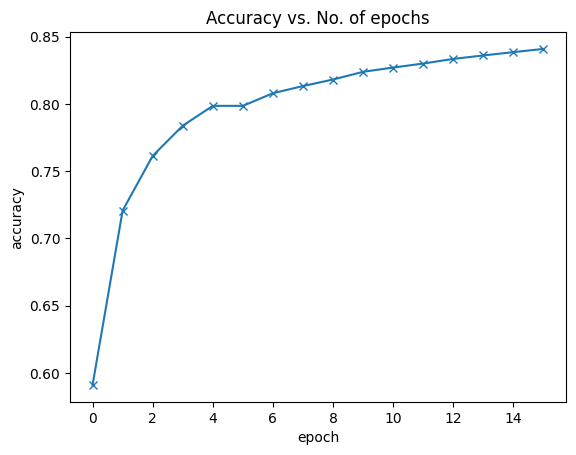

In [84]:
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs. No. of epochs');

# now trying to know what happens if we donot define forward function i.e def forward()

In [88]:
class falseMnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
        
    
        
    def training_step(self, batch):
        images, labels = batch
        out = self(images) # generate predictions
        loss = F.cross_entropy(out, labels)
        return loss
        
    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss':loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean() # combine losses
        batch_accs = [x['val_acc']for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean() # combine accuracies
        return {'val_loss':epoch_loss.item(), 'val_acc':epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

    def evaluate(self, val_loader):
        outputs = [self.validation_step(batch) for batch in val_loader]
        return self.validation_epoch_end(outputs)

In [86]:
false_model = falseMnistModel()

In [87]:
false_model.evaluate(val_loader)

NotImplementedError: Module [falseMnistModel] is missing the required "forward" function

# 🧠 Deep Learning Concepts: The `forward` Function

In modern deep learning (PyTorch, TensorFlow), the `forward` function is the core of your model's architecture.

---

### 1. What is it exactly?
The **forward function** is the **Main Mathematical Function** of your model ($y = f(x)$). 

While the `fit` method (or training loop) handles the overall process of learning, the `forward` function defines the specific logic of how input data is transformed into an output. It is the **"computation graph"** that defines how data flows through your layers.

---

### 2. The Two-Part System
Deep learning consists of two separate mathematical engines working together:

1.  **The Forward Pass (The Predictor):** 
    *   **Function:** Defined by the `forward` method.
    *   **Role:** Takes input $x$, multiplies it by weights, adds biases, and applies activations.
    *   **Output:** A prediction (guess).

2.  **The Backward Pass (The Teacher):**
    *   **Function:** Handled by the **Optimizer** and **Loss Function**.
    *   **Role:** Measures the error of the prediction and updates the weights in the `forward` function to be more accurate next time.

> **Key Insight:** The `forward` function is the model's "brain" (how it thinks), while the weight-update logic is the "tutor" (how it learns from mistakes).

---

### 3. Why is it Mandatory?
When you inherit from `nn.Module` (PyTorch), you are required to define `forward` because:

*   **The Framework Expects It:** When you run `model(input)`, the library internally triggers the code inside the `forward` method.
*   **Calculus Mapping:** To update weights, the computer needs to know the exact path the data took. The `forward` function provides this "map." Without it, the computer wouldn't know how to perform the **Backward Pass** (calculating gradients).
*   **Customization:** It allows you to build complex logic—like splitting data into two paths or skipping layers—that a simple list of layers cannot describe.

---

### 4. Code Structure Breakdown

```python
import torch.nn as nn

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        # STEP 1: Define the "Parts" (the layers/parameters)
        self.layer1 = nn.Linear(10, 5)
        self.layer2 = nn.Linear(5, 1)

    def forward(self, x):
        # STEP 2: Define the "Logic" (the main math function)
        # This is where the actual computation happens
        x = self.layer1(x)
        x = nn.functional.relu(x)
        x = self.layer2(x)
        return x


# 🛡️ How to Stop a Model from "Memorizing" (Overfitting)

In Deep Learning, memorization is called **Overfitting**. We use the **Validation Set** as a "lie detector" to catch the model if it stops learning and starts memorizing.

### 1. The Validation "Tug-of-War"
While the model is training, we monitor the **Loss** (error) for both sets:

*   **Learning:** Both Training Loss and Validation Loss go **down** together. The model is finding general patterns that work everywhere.
*   **Memorizing:** Training Loss continues to go **down**, but Validation Loss starts to go **up**. This is the "Red Alert" that the model is just memorizing the training images and failing on the unseen validation images.

### 2. Techniques to Force "Learning" over "Memorizing"

If our validation score shows the model is memorizing, we use these tools:

*   **Regularization (Weight Decay):** We mathematically "penalize" the model for having weights that are too large or complex. It forces the model to keep its math simple.
*   **Dropout:** During the `forward` function, we randomly "turn off" some neurons. This forces the model to not rely on any single pixel or path, making it learn multiple ways to identify a digit.
*   **Early Stopping:** We stop the `fit` process the exact moment the Validation Loss stops improving, even if the Training Loss is still getting better.
*   **Data Augmentation:** we slightly tilt, zoom, or shift the training images. This makes it impossible for the model to memorize a specific "pixel map" because the image looks slightly different every time it sees it.

### 3. Summary of the Goal
We want the model to learn the **"essence"** of a digit (the curves and lines) so that when it sees a brand new version of a "7" in the **Test Set**, it recognizes the shape rather than looking for a specific photo it saw during training.

| Result | Training Accuracy | Validation Accuracy | Meaning |
| :--- | :--- | :--- | :--- |
| **Underfitting** | Low | Low | Model hasn't learned anything yet. |
| **Overfitting** | High | Low | **Memorization.** (Model is cheating). |
| **Generalization**| High | High | **Learning.** (Model understands the concept). |


# __testing with inidividual images__

In [90]:
test_dataset = MNIST(root='data/', train=False, transform= transforms.ToTensor())

In [91]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: data/
    Split: Test
    StandardTransform
Transform: ToTensor()

Shape: torch.Size([1, 28, 28])
Label: 7


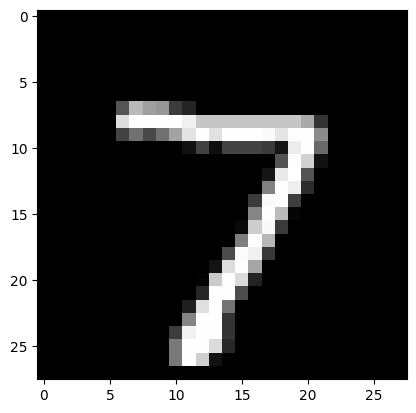

In [92]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap='gray')
print('Shape:', img.shape)
print('Label:', label)

In [93]:
def predict_image(img, model):
    xb = img.unsqueeze(0)
    yb = model(xb)
    _, preds = torch.max(yb, dim=1)
    return preds[0].item()

__img.unsqueeze simply adds another dimension at the begining of the 1x28x28 tensor, making it a 1x1x28x28 tensor, which the model views as a batch containing a single image.__



Label: 7 , Predicted 7


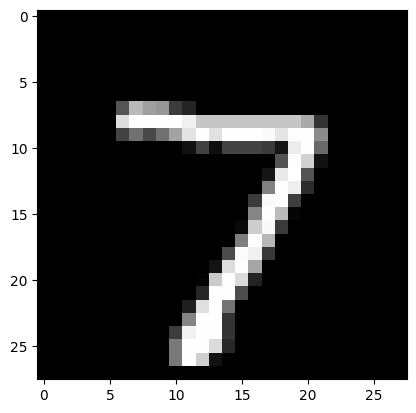

In [94]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted', predict_image(img, model))

In [97]:
torch.max(model(img[0]))


tensor(3.8911, grad_fn=<MaxBackward1>)

In [98]:
model(img[0])

tensor([[-0.4650, -2.0261, -0.5387, -0.0761, -0.1462, -0.5798, -1.4566,  3.8911,
         -0.2862,  1.2012]], grad_fn=<AddmmBackward0>)

Label: 0 ,Predicted: 0


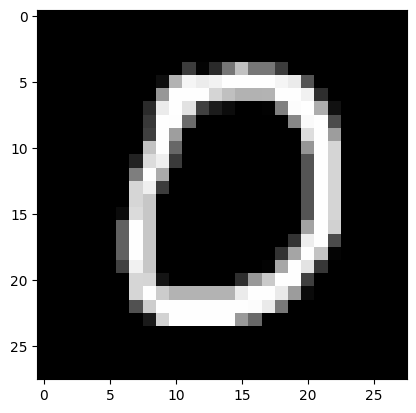

In [110]:
img, label = test_dataset[10]
img.shape
plt.imshow(img[0], cmap='gray')
print('Label:', label, ',Predicted:', predict_image(img, model))

In [107]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [109]:
img[0].shape

torch.Size([28, 28])

Label: 9 , Predicted: 4


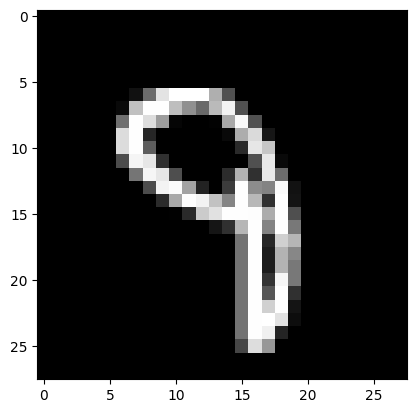

In [114]:
img, label = test_dataset[193]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted:', predict_image(img, model))

__Identifying where our model performs poorly can help us improve the model, by collecting more training data, increasing/decreasing the complexity of the model, and changing the hypeparameters.__

__As a final step, let's also look at the overall loss and accuracy of the model on the test set.__

In [115]:
test_loader = DataLoader(test_dataset, batch_size=256)
result = model.evaluate(test_loader)
result

{'val_loss': 0.7241288423538208, 'val_acc': 0.852734386920929}

We expect this to be similar to the accuracy/loss on the validation set. If not, we might need a better validation set that has similar data and distribution as the test set (which often comes from real world data).

In [117]:
result_vald = model.evaluate(val_ds)
result_vald

TypeError: cross_entropy_loss(): argument 'target' (position 2) must be Tensor, not int

In [122]:
val_ds

In [125]:
torch.save(model.state_dict(), 'mnist-logistic.pth')

The .state_dict method returns an OrderedDict containing all the weights and bias matrices mapped to the right attributes of the model.


In [126]:
model.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.0342,  0.0064,  0.0211,  ..., -0.0194,  0.0229,  0.0351],
                      [-0.0076,  0.0220, -0.0030,  ..., -0.0276,  0.0297, -0.0306],
                      [-0.0149, -0.0239, -0.0054,  ..., -0.0187,  0.0290, -0.0314],
                      ...,
                      [-0.0048,  0.0033,  0.0155,  ...,  0.0033,  0.0191,  0.0271],
                      [ 0.0027, -0.0051, -0.0347,  ...,  0.0181, -0.0154,  0.0075],
                      [ 0.0135, -0.0211,  0.0226,  ...,  0.0194, -0.0181,  0.0017]])),
             ('linear.bias',
              tensor([-0.0348,  0.1076,  0.0070,  0.0041,  0.0323,  0.0238,  0.0072,  0.0280,
                      -0.0546, -0.0081]))])

In [130]:
model2 = model

In [131]:
model2.evaluate(test_loader)

{'val_loss': 0.7241288423538208, 'val_acc': 0.852734386920929}

In [132]:
model2.load_state_dict(torch.load('mnist-logistic.pth'))
model2.state_dict()

C:\Users\Prasad\AppData\Local\Temp\ipykernel_26052\468328532.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load('mnist-logistic.pth'))


OrderedDict([('linear.weight',
              tensor([[ 0.0342,  0.0064,  0.0211,  ..., -0.0194,  0.0229,  0.0351],
                      [-0.0076,  0.0220, -0.0030,  ..., -0.0276,  0.0297, -0.0306],
                      [-0.0149, -0.0239, -0.0054,  ..., -0.0187,  0.0290, -0.0314],
                      ...,
                      [-0.0048,  0.0033,  0.0155,  ...,  0.0033,  0.0191,  0.0271],
                      [ 0.0027, -0.0051, -0.0347,  ...,  0.0181, -0.0154,  0.0075],
                      [ 0.0135, -0.0211,  0.0226,  ...,  0.0194, -0.0181,  0.0017]])),
             ('linear.bias',
              tensor([-0.0348,  0.1076,  0.0070,  0.0041,  0.0323,  0.0238,  0.0072,  0.0280,
                      -0.0546, -0.0081]))])

In [133]:
test_loader = DataLoader(test_dataset, batch_size=256)
result = model2.evaluate(test_loader)
result

{'val_loss': 0.7241288423538208, 'val_acc': 0.852734386920929}

This project successfully demonstrated the implementation of a basic linear model for classifying handwritten digits from the MNIST dataset using PyTorch. While the achieved accuracy with a simple linear layer might not be as high as that attainable with more sophisticated architectures like Convolutional Neural Networks (CNNs), this exercise has provided valuable insights into the core principles of neural network training.

Key Takeaways:

Linear Models and their Limitations:

Linear models, despite their simplicity, offer a foundational understanding of how neural networks operate.
In the context of image classification, linear models have limitations. They struggle to capture complex spatial relationships and features within images.
For instance, a linear model might not be able to effectively recognize rotated or slightly distorted digits due to its inability to learn local features and invariant representations.
Importance of Data Preprocessing:

Data preprocessing plays a crucial role in the success of any machine learning model.
In this project, we observed the importance of:
Normalization: Scaling the pixel values to a specific range (e.g., [-1, 1]) can significantly improve model performance and training stability.
Data Augmentation (not implemented in this example): Techniques such as rotation, translation, and scaling can artificially increase the size of the training dataset and improve the model's generalization ability.
Neural Network Training Process:

This project provided hands-on experience with the key steps involved in training a neural network:
Model Definition: Defining the architecture of the model, including the number of layers, neurons, and activation functions.
Loss Function: Selecting an appropriate loss function to measure the discrepancy between the model's predictions and the ground truth.
Optimizer: Choosing an optimization algorithm (e.g., SGD, Adam) to update the model's parameters based on the gradients of the loss function.
Training Loop: Iteratively updating the model's parameters by processing batches of training data, calculating the loss, and performing backpropagation.
Evaluation: Assessing the model's performance on unseen data (test set) to evaluate its generalization ability.
Path Forward:

This project serves as a stepping stone for exploring more complex and powerful neural network architectures for image classification, such as:
Convolutional Neural Networks (CNNs): CNNs are specifically designed to efficiently process image data by leveraging convolutional layers to extract local features.
Recurrent Neural Networks (RNNs): RNNs are suitable for sequential data, although less common for image classification.
In summary, this project has provided a valuable foundation in understanding the core principles of neural network training and has highlighted the importance of appropriate model selection and data preprocessing for successful image classification tasks.

This expanded conclusion provides a more in-depth and theoretically grounded discussion of the key takeaways from the project.

In [ ]:
# root='data/', train=True, download=True,transform=transforms.ToTensor()

# Exercise MNIST

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
from torchvision.datasets import FashionMNIST

In [4]:
fashion_data = FashionMNIST(root='data/', train=True, download=True, transform=transforms.ToTensor())

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:11<00:00, 2.30MB/s]


Extracting data/FashionMNIST\raw\train-images-idx3-ubyte.gz to data/FashionMNIST\raw



100%|██████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 159kB/s]


Extracting data/FashionMNIST\raw\train-labels-idx1-ubyte.gz to data/FashionMNIST\raw



100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:02<00:00, 1.60MB/s]


Extracting data/FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data/FashionMNIST\raw



100%|█████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting data/FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data/FashionMNIST\raw



In [5]:
fashion_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
fashion_test = FashionMNIST(root='data/', train=False, download=True, transform=transforms.ToTensor())

In [7]:
fashion_test

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data/
    Split: Test
    StandardTransform
Transform: ToTensor()

In [9]:
len(fashion_test)

10000

In [11]:
im, lb = fashion_data[0]
print(im.shape, lb)

torch.Size([1, 28, 28]) 9


In [13]:
fashion_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

TypeError: Invalid shape (1, 28, 28) for image data

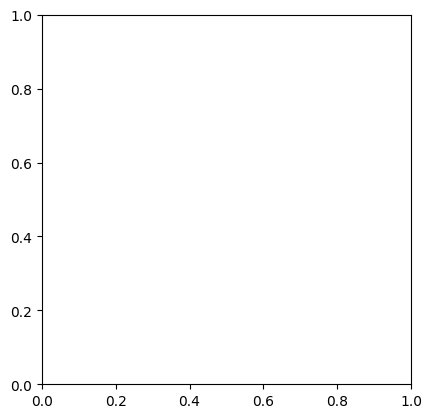

In [14]:
im. lb = fashion_data[0]
plt.imshow(im, cmap='gray')
print('Label:', lb)

Label: 9


C:\Users\Prasad\AppData\Local\Temp\ipykernel_22312\1718355944.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3687.)
  plt.imshow(im.T[:-2], cmap='gray')


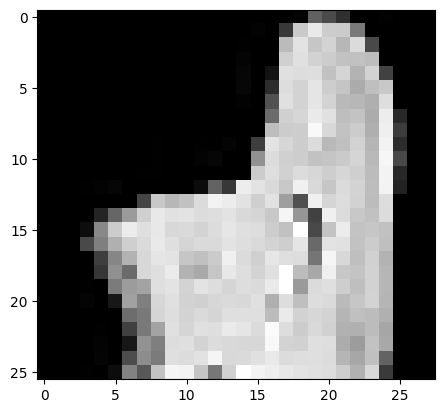

In [15]:
im, lb = fashion_data[0]
plt.imshow(im.T[:-2], cmap='gray')
print('Label:', lb)

Label: 0


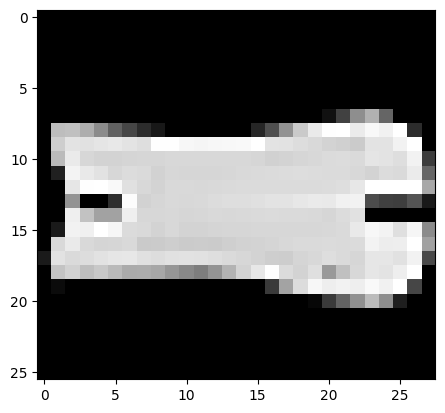

In [20]:
im, lb = fashion_data[4]
plt.imshow(im.T[:-2], cmap='gray')
print("Label:", lb)

In [31]:
print(im.shape, lb)

torch.Size([1, 28, 28]) 0


0 - trshirt / top 

1 Trouser

2 Pullover

3 Dress

4 Coat 

5 Sandal

6 shirt

7 sneaker

8 bag

9 ankle boot


In [22]:
from torch.utils.data import random_split

f_train, f_val = random_split(fashion_data, [50000, 10000])
len(f_train), len(f_val)

(50000, 10000)

In [27]:
len(fashion_data)

60000

In [23]:
from torch.utils.data import DataLoader

batch_size = 128

f_trn_loader = DataLoader(f_train, batch_size, shuffle=True)
f_vl_loader = DataLoader(f_val, batch_size)

In [32]:
import torch.nn as nn

input_size = 28 * 28
num_classes = 10



In [33]:
def accuracy(outputs, label):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds==labels).item())/len(preds)

In [35]:
import torch.nn.functional as F
loss_fn = F.cross_entropy


loss = loss_fn(outputs, labels)


NameError: name 'outputs' is not defined

In [36]:
class FashionMnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1 ,784)
        out = self.linear(xb)
        return out

    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss, "val_acc":acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_accs).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss:': epoch_loss.item(), 'val_acc':epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

    def evaluate(self, val_loader):
        outputs = [self.validation_step(batch) for batch in val_loader]
        return self.validation_epoch_end(outputs)
    

In [39]:
model_fashion = FashionMnistModel()

In [41]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    optimizer = opt_func(model.parameters(), lr)
    history = []

    for epoch in range(epochs):
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = model.evaluate(val_loader)
        model.epoch_end(epoch, result)
        history.append(result)

    return history
    

In [42]:
wer = fit(5, 0.001, model_fashion, f_trn_loader, f_vl_loader)

NameError: name 'labels' is not defined

In [ ]:
for img, lbl in f_trn_loader:
    print(lbl)
    print()

Q1: Why do we normalize images to the range [−1,1][-1,1][−1,1] instead of keeping raw pixel values?
Q2: What does the Linear Layer do in a neural network?

Q3: Why do we use CrossEntropyLoss for classification tasks?
Q4: How does SGD optimizer work, and what is the effect of learning rate?

Q5: How can we improve accuracy in this model? Suggest some possible changes.

